In [250]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm, t
from scipy.stats import expon
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title ,xlabel,ylabel
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)


from sklearn.linear_model import ElasticNet
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [2]:
a = pd.read_csv(r"C:\Users\yzope\Downloads\payment_history.csv")
b = pd.read_csv(r"C:\Users\yzope\Downloads\monthly_emi_track.csv")
c = pd.read_csv(r"C:\Users\yzope\Downloads\loans_master.csv")
d = pd.read_csv(r"C:\Users\yzope\Downloads\loan_performance.csv")
e = pd.read_csv(r"C:\Users\yzope\Downloads\collateral_assets.csv")
f = pd.read_csv(r"C:\Users\yzope\Downloads\loan_enquiry_bureau.csv")
g = pd.read_csv(r"C:\Users\yzope\Downloads\customer_bureau.csv")
h = pd.read_csv(r"C:\Users\yzope\Downloads\credit_card_behavior.csv")
i = pd.read_csv(r"C:\Users\yzope\Downloads\branch_region_economy.csv")

In [3]:
a.head()

,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr
0,LN000000001,0,0.0,102327.83,98339.43,80678.0,21649.83,13922.84,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
1,LN000000002,0,0.0,319635.13,309461.58,274166.0,45469.13,22957.63,0.0,0.0,0.0,0.0,1,0,1,0,0.0,0.0
2,LN000000003,0,0.0,79687.39,78661.62,59603.0,20084.39,NaN,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
3,LN000000004,0,0.0,509995.37,492937.00,246313.0,263682.37,13529.63,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0
4,LN000000005,0,0.0,126155.61,126048.04,101471.0,24684.61,9962.35,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0


In [4]:
b.head()

,loan_id,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,avg_payment_delay_days,payment_mode,emi_bank_name,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline
0,LN000000001,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.0,0,0.0,UPI,Union,0.00,0,0.0,0,0,0,3.99,6.0,0.2504,Excellent
1,LN000000002,8465.45,304756.20,308223.00,0.00,1,0,May-2024,0.0,0,5.0,NACH,SBI,1488.08,0,0.0,0,0,0,8.95,6.0,0.1117,Good
2,LN000000003,1366.55,81993.00,83657.21,0.00,1,0,Sep-2022,0.0,0,0.0,UPI,SBI,932.45,0,0.0,0,0,0,8.54,3.0,0.1171,Good
3,LN000000004,6088.88,511465.92,496707.66,14758.26,1,0,Jan-2023,0.0,0,0.0,Net Banking,ICICI,807.41,0,0.0,0,0,0,3.64,2.0,0.2750,Good
4,LN000000005,2082.81,124968.60,120842.83,4125.77,0,0,May-2017,0.0,0,0.0,Net Banking,ICICI,0.00,0,0.0,0,0,0,61.18,2.0,0.0163,Excellent


In [5]:
c.head()

,loan_id,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,grade,sub_grade,loan_purpose,state_code,region,urban_index,application_type,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct
0,LN000000001,Feb-2016,2016,2,80678.0,74992.0,36,14.91,2793.17,33518.0,C,C5,education,OR,East,0.33,Individual,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.66,10.41
1,LN000000002,May-2024,2024,5,274166.0,265041.0,36,7.00,8465.45,101585.0,A,A5,small_business,JH,East,0.36,Individual,N,N,w,CASH,Verified,6.50,6.8,4.9,0.50,2.10
2,LN000000003,Dec-2021,2021,12,59603.0,54423.0,60,13.34,1366.55,16399.0,D,D5,home_improvement,TN,South,0.72,Individual,N,N,w,DIRECT_PAY,Source Verified,4.00,8.7,5.1,9.34,8.24
3,LN000000004,Nov-2020,2020,11,246313.0,224181.0,84,24.07,6088.88,73067.0,G,G5,home_improvement,RJ,North,0.45,Joint App,N,N,w,DIRECT_PAY,Source Verified,4.00,-6.6,6.2,20.07,17.87
4,LN000000005,Jul-2013,2013,7,101471.0,95361.0,60,8.52,2082.81,24994.0,A,A5,vacation,DL,North,0.97,Individual,Y,N,w,CASH,Verified,7.75,6.4,10.9,0.77,-2.38


In [6]:
#here the dtypes are in float64
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 18 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   loan_id                   object 
 1   loan_status               int64  
 2   lgd_pct                   float64
 3   total_pymnt_inr           float64
 4   total_pymnt_inv_inr       float64
 5   total_rec_prncp_inr       float64
 6   total_rec_int_inr         float64
 7   last_pymnt_amnt_inr       float64
 8   out_prncp_inr             float64
 9   out_prncp_inv_inr         float64
 10  collection_recovery_fee   float64
 11  collections_12mths_fee    float64
 12  mths_since_last_pymnt     int64  
 13  num_accts_ever_120_pd     int64  
 14  num_derog_rec             int64  
 15  acc_now_delinq            int64  
 16  chargeoff_within_12_mths  float64
 17  expected_loss_inr         float64
dtypes: float64(12), int64(5), object(1)
memory usage: 274.7+ MB


In [7]:
a.head()

,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr
0,LN000000001,0,0.0,102327.83,98339.43,80678.0,21649.83,13922.84,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
1,LN000000002,0,0.0,319635.13,309461.58,274166.0,45469.13,22957.63,0.0,0.0,0.0,0.0,1,0,1,0,0.0,0.0
2,LN000000003,0,0.0,79687.39,78661.62,59603.0,20084.39,NaN,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0
3,LN000000004,0,0.0,509995.37,492937.00,246313.0,263682.37,13529.63,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0
4,LN000000005,0,0.0,126155.61,126048.04,101471.0,24684.61,9962.35,0.0,0.0,0.0,0.0,2,0,0,0,0.0,0.0


In [8]:
#here we have merged all the datasets 
df = a.merge(b,on='loan_id',how='left').merge(c,on='loan_id',how='left').merge(d,on='loan_id',how='left').merge(e,on='loan_id',how='left').merge(f,on='loan_id',how='left').merge(g,on='loan_id',how='left').merge(h,on='loan_id',how='left').merge(i,on='loan_id',how='left')

In [9]:
#all of the columns from all 9 datasets are been merged here
df.head()

,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,avg_payment_delay_days,payment_mode,emi_bank_name,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,grade,sub_grade,loan_purpose,state_code,region,urban_index,application_type,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct,dpd_bucket,npa_flag,risk_tier,cibil_score_band,recoveries_inr,recovery_fee_rate,policy_code,hardship_amount_inr,hardship_length_mths,net_loss_inr,provision_inr,has_collateral,collateral_type,collateral_value_inr,ltv_ratio_pct,loan_secured_flag,property_type,property_age_years,property_area_sqft,property_city_tier,vehicle_type,vehicle_age_years,insurance_flag,valuation_date,valuation_agency,charge_type,collateral_score,prop_value_inr,vehicle_value_inr,business_asset_val_inr,num_enquiries_30d,num_enquiries_90d,num_enquiries_6m,num_enquiries_12m,num_enquiries_24m,primary_enq_purpose,unique_lenders_enquired,rejected_applications,approved_applications,rejection_rate_pct,income_doc_type,kyc_status,field_verification_status,credit_committee_flag,loan_approved_date,processing_days,sourcing_channel,sourcing_agent_type,policy_deviation_flag,policy_override_flag,sanctioned_amount_inr,disbursed_amount_inr,tat_within_sla_flag,customer_id,age,gender,emp_title,emp_length_years,home_ownership,annual_inc_inr,dti_pct,cibil_score,earliest_cr_line,credit_hist_years,revol_bal_inr,revol_util_pct,open_acc,total_acc,mort_acc,pub_rec,delinq_2yrs,num_inq_last6m,num_inq_last12m,pct_tl_nvr_dlq,total_rev_hi_lim_inr,bc_util_pct,il_util_pct,all_util_pct,avg_cur_bal_inr,mths_since_last_delinq,mths_since_last_record,num_tl_op_past_12m,has_credit_card,num_credit_cards,total_cc_limit_inr,total_cc_balance_inr,cc_utilization_pct,cc_late_payments_count,cc_overlimit_count,cash_advance_inr,primary_card_type,primary_cc_bank,cc_spend_last3m_inr,avg_monthly_cc_spend_inr,top_spend_category,cc_payment_score,cc_default_risk_score,cc_emi_conversion_flag,branch_id,district_type,state_per_capita_inc_inr,state_literacy_rate_pct,state_agri_share_pct,state_industry_share_pct,state_services_share_pct,district_gdp_growth_pct,branch_age_years,branch_size,loan_officer_exp_years,branch_npa_rate,branch_sanction_rate,infrastructure_index,financial_inclusion_idx,credit_penetration_idx,covid_issue_year_flag,poor_monsoon_year_flag
0,LN000000001,0,0.0,102327.83,98339.43,80678.0,21649.83,13922.84,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.0,0,0.0,UPI,Union,0.00,0,0.0,0,0,0,3.99,6.0,0.2504,Excellent,Feb-2016,2016,2,80678.0,74992.0,36,14.91,2793.17,33518.0,C,C5,education,OR,East,0.33,Individual,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.66,10.41,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,397.93,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,May-2016,NaN,NaN,0.0,0.0,0.0,0.0,0,3,5,8,16,Personal Loan,3,0,8,0.0,NaN,Complete,Pending,0,Jan-2016,17.0,Branch,Online,0,0,74537.0,73139.0,0,CU01240276,45,M,Salaried,0.0,RENT,133866.0,14.99,624,Jun-1989,26.57,12242.63,27.8,11,27,0.0,0.0,0.0,5.0,7.0,65.4,763.84,25.9,75.9,43.1,1112.97,NaN,NaN,3,1,2,74592.0,39358.0,52.8,0,0,0.0,Basic,SBI,14230.0,4743.0,Online,100.0,0.2640,0,BR6893-OR,Urban,78000,72.9,28,30,42,7.25,26,Small,5.0,0.0536,0.7

In [10]:
#shape indicates rows and columns
df.shape

(2000000, 182)

In [11]:
before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory Before Downcasting: {before:.2f} MB")

Memory Before Downcasting: 6608.61 MB


In [12]:
#here we have downcast the dtypes according to requirments 
for col in df.select_dtypes(include=['int']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Columns: 182 entries, loan_id to poor_monsoon_year_flag
dtypes: float32(55), float64(29), int16(3), int32(1), int8(49), object(45)
memory usage: 1.6+ GB


In [14]:
after = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory After Downcasting: {after:.2f} MB")
print(f"Saved: {before-after:.2f} MB")
print(f"Reduction: {((before-after)/before)*100:.2f}%")

Memory After Downcasting: 5492.81 MB
Saved: 1115.80 MB
Reduction: 16.88%


In [15]:
#here we have have converted to parquet file which means we are compressing the file size
df.to_parquet("edaFinal.parquet",index=False)

In [16]:
df = pd.read_parquet("edaFinal.parquet")

In [17]:
print(f"Parquet DF Memory: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

Parquet DF Memory: 5406.16 MB


In [18]:
df.head()

,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,avg_payment_delay_days,payment_mode,emi_bank_name,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,grade,sub_grade,loan_purpose,state_code,region,urban_index,application_type,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct,dpd_bucket,npa_flag,risk_tier,cibil_score_band,recoveries_inr,recovery_fee_rate,policy_code,hardship_amount_inr,hardship_length_mths,net_loss_inr,provision_inr,has_collateral,collateral_type,collateral_value_inr,ltv_ratio_pct,loan_secured_flag,property_type,property_age_years,property_area_sqft,property_city_tier,vehicle_type,vehicle_age_years,insurance_flag,valuation_date,valuation_agency,charge_type,collateral_score,prop_value_inr,vehicle_value_inr,business_asset_val_inr,num_enquiries_30d,num_enquiries_90d,num_enquiries_6m,num_enquiries_12m,num_enquiries_24m,primary_enq_purpose,unique_lenders_enquired,rejected_applications,approved_applications,rejection_rate_pct,income_doc_type,kyc_status,field_verification_status,credit_committee_flag,loan_approved_date,processing_days,sourcing_channel,sourcing_agent_type,policy_deviation_flag,policy_override_flag,sanctioned_amount_inr,disbursed_amount_inr,tat_within_sla_flag,customer_id,age,gender,emp_title,emp_length_years,home_ownership,annual_inc_inr,dti_pct,cibil_score,earliest_cr_line,credit_hist_years,revol_bal_inr,revol_util_pct,open_acc,total_acc,mort_acc,pub_rec,delinq_2yrs,num_inq_last6m,num_inq_last12m,pct_tl_nvr_dlq,total_rev_hi_lim_inr,bc_util_pct,il_util_pct,all_util_pct,avg_cur_bal_inr,mths_since_last_delinq,mths_since_last_record,num_tl_op_past_12m,has_credit_card,num_credit_cards,total_cc_limit_inr,total_cc_balance_inr,cc_utilization_pct,cc_late_payments_count,cc_overlimit_count,cash_advance_inr,primary_card_type,primary_cc_bank,cc_spend_last3m_inr,avg_monthly_cc_spend_inr,top_spend_category,cc_payment_score,cc_default_risk_score,cc_emi_conversion_flag,branch_id,district_type,state_per_capita_inc_inr,state_literacy_rate_pct,state_agri_share_pct,state_industry_share_pct,state_services_share_pct,district_gdp_growth_pct,branch_age_years,branch_size,loan_officer_exp_years,branch_npa_rate,branch_sanction_rate,infrastructure_index,financial_inclusion_idx,credit_penetration_idx,covid_issue_year_flag,poor_monsoon_year_flag
0,LN000000001,0,0.0,102327.83,98339.43,80678.0,21649.83,13922.84,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.0,0,0.0,UPI,Union,0.00,0,0.0,0,0,0,3.99,6.0,0.2504,Excellent,Feb-2016,2016,2,80678.0,74992.0,36,14.91,2793.17,33518.0,C,C5,education,OR,East,0.33,Individual,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.66,10.410000,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,397.93,0,None,0.0,NaN,0,None,0,0,None,None,0,0,May-2016,None,None,0.000000,0.0,0.0,0.0,0,3,5,8,16,Personal Loan,3,0,8,0.0,None,Complete,Pending,0,Jan-2016,17.0,Branch,Online,0,0,74537.0,73139.0,0,CU01240276,45,M,Salaried,0.0,RENT,133866.0,14.990000,624,Jun-1989,26.57,12242.63,27.799999,11,27,0.0,0.0,0.0,5.0,7.0,65.400002,763.84,25.900000,75.900002,43.099998,1112.97,NaN,NaN,3,1,2,74592.0,39358.0,52.799999,0,0,0.0,Basic,SBI,14230.0,4743.0,Online,100.0,0.2640,0,BR6893-OR,Urba

In [19]:
#Identify dirty records: int_rate_pct<0, annual_inc_inr==0, dti_pct>100, revol_util_pct<0. Create a dirty_flag binary column. Do NOT delete these rows — flag and impute.

df['dirty_flag'] = np.where(
    (
        (df['int_rate_pct'] < 0) |
        (df['annual_inc_inr'] == 0) |
        (df['dti_pct'] > 100) |
        (df['revol_util_pct'] < 0)
    ),
    1,
    0
)

In [20]:
print("Negative Interest:", (df['int_rate_pct'] < 0).sum())

print("Zero Income:", (df['annual_inc_inr'] == 0).sum())

print("DTI >100:", (df['dti_pct'] > 100).sum())

print("Negative Revol Util:",
      (df['revol_util_pct'] < 0).sum())

Negative Interest: 0
Zero Income: 0
DTI >100: 0
Negative Revol Util: 0


In [21]:
'''
MCAR (Missing Completely At Random) : missing has nothing to do with any variable in the dataset.
MAR (Missing At Random):Missingness depends on other observed variables, but not on the missing value itself.
MNAR (Missing Not At Random):Missingness depends on the value itself.
'''

'\nMCAR (Missing Completely At Random)\nMAR (Missing At Random)\nMNAR (Missing Not At Random)\n'

In [22]:
#here we figured out houmuch missing walues are been present in the df
missing_cols = [
    'mths_since_last_delinq',
    'mort_acc',
    'emp_length_years',
    'il_util_pct'
]

df[missing_cols].isnull().sum()

mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64

In [23]:
#here we converted it in terms of percentage
(df[missing_cols].isnull().sum() / len(df))*100

mths_since_last_delinq    54.93200
mort_acc                  13.01650
emp_length_years           9.02695
il_util_pct               10.00835
dtype: float64

In [50]:
df.columns

Index(['loan_id', 'loan_status', 'lgd_pct', 'total_pymnt_inr',
       'total_pymnt_inv_inr', 'total_rec_prncp_inr', 'total_rec_int_inr',
       'last_pymnt_amnt_inr', 'out_prncp_inr', 'out_prncp_inv_inr',
       ...
       'branch_size', 'loan_officer_exp_years', 'branch_npa_rate',
       'branch_sanction_rate', 'infrastructure_index',
       'financial_inclusion_idx', 'credit_penetration_idx',
       'covid_issue_year_flag', 'poor_monsoon_year_flag', 'dirty_flag'],
      dtype='object', length=183)

In [54]:
df.head()

,loan_id,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,avg_payment_delay_days,payment_mode,emi_bank_name,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,grade,sub_grade,loan_purpose,state_code,region,urban_index,application_type,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct,dpd_bucket,npa_flag,risk_tier,cibil_score_band,recoveries_inr,recovery_fee_rate,policy_code,hardship_amount_inr,hardship_length_mths,net_loss_inr,provision_inr,has_collateral,collateral_type,collateral_value_inr,ltv_ratio_pct,loan_secured_flag,property_type,property_age_years,property_area_sqft,property_city_tier,vehicle_type,vehicle_age_years,insurance_flag,valuation_date,valuation_agency,charge_type,collateral_score,prop_value_inr,vehicle_value_inr,business_asset_val_inr,num_enquiries_30d,num_enquiries_90d,num_enquiries_6m,num_enquiries_12m,num_enquiries_24m,primary_enq_purpose,unique_lenders_enquired,rejected_applications,approved_applications,rejection_rate_pct,income_doc_type,kyc_status,field_verification_status,credit_committee_flag,loan_approved_date,processing_days,sourcing_channel,sourcing_agent_type,policy_deviation_flag,policy_override_flag,sanctioned_amount_inr,disbursed_amount_inr,tat_within_sla_flag,customer_id,age,gender,emp_title,emp_length_years,home_ownership,annual_inc_inr,dti_pct,cibil_score,earliest_cr_line,credit_hist_years,revol_bal_inr,revol_util_pct,open_acc,total_acc,mort_acc,pub_rec,delinq_2yrs,num_inq_last6m,num_inq_last12m,pct_tl_nvr_dlq,total_rev_hi_lim_inr,bc_util_pct,il_util_pct,all_util_pct,avg_cur_bal_inr,mths_since_last_delinq,mths_since_last_record,num_tl_op_past_12m,has_credit_card,num_credit_cards,total_cc_limit_inr,total_cc_balance_inr,cc_utilization_pct,cc_late_payments_count,cc_overlimit_count,cash_advance_inr,primary_card_type,primary_cc_bank,cc_spend_last3m_inr,avg_monthly_cc_spend_inr,top_spend_category,cc_payment_score,cc_default_risk_score,cc_emi_conversion_flag,branch_id,district_type,state_per_capita_inc_inr,state_literacy_rate_pct,state_agri_share_pct,state_industry_share_pct,state_services_share_pct,district_gdp_growth_pct,branch_age_years,branch_size,loan_officer_exp_years,branch_npa_rate,branch_sanction_rate,infrastructure_index,financial_inclusion_idx,credit_penetration_idx,covid_issue_year_flag,poor_monsoon_year_flag,dirty_flag
0,LN000000001,0,0.0,102327.83,98339.43,80678.0,21649.83,13922.84,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.0,0,0.0,UPI,Union,0.00,0,0.0,0,0,0,3.99,6.0,0.2504,Excellent,Feb-2016,2016,2,80678.0,74992.0,36,14.91,2793.17,33518.0,C,C5,education,OR,East,0.33,Individual,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.66,10.410000,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,397.93,0,None,0.0,NaN,0,None,0,0,None,None,0,0,May-2016,None,None,0.000000,0.0,0.0,0.0,0,3,5,8,16,Personal Loan,3,0,8,0.0,None,Complete,Pending,0,Jan-2016,17.0,Branch,Online,0,0,74537.0,73139.0,0,CU01240276,45,M,Salaried,0.0,RENT,133866.0,14.990000,624,Jun-1989,26.57,12242.63,27.799999,11,27,0.0,0.0,0.0,5.0,7.0,65.400002,763.84,25.900000,75.900002,43.099998,1112.97,NaN,NaN,3,1,2,74592.0,39358.0,52.799999,0,0,0.0,Basic,SBI,14230.0,4743.0,Online,100.0,0.2640,0,BR6

In [68]:
#here we checked wheather our column contains any of null values or not 

#Na,NaN,Null all of them are same

null_count = df.isnull().sum()
null_count = null_count[null_count > 0]
print(null_count)

last_pymnt_amnt_inr           119889
collection_recovery_fee       120086
avg_payment_delay_days        120364
emi_bank_name                 120236
pdc_count                     120057
cibil_score_band                  10
collateral_type              1258896
ltv_ratio_pct                1472196
property_type                1679672
property_city_tier           1679672
vehicle_type                 1879789
valuation_agency             1370048
charge_type                  1258896
collateral_score              298379
income_doc_type               308704
field_verification_status     119475
processing_days               119899
emp_length_years              180539
annual_inc_inr                 40066
revol_util_pct                140097
mort_acc                      260330
pub_rec                       118951
delinq_2yrs                   100207
num_inq_last6m                 80130
pct_tl_nvr_dlq                 59892
bc_util_pct                   160397
il_util_pct                   200167
a

#d:find missing values and fill them 

In [80]:
# Negative Interest Rate
df.loc[
    df['int_rate_pct'] < 0,
    'int_rate_pct'
] = np.nan

df['int_rate_pct'] = (
    df.groupby('grade')['int_rate_pct']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

# Zero Income
df.loc[
    df['annual_inc_inr'] <= 0,
    'annual_inc_inr'
] = np.nan

df['annual_inc_inr'] = (
    df.groupby('emp_title')
      ['annual_inc_inr']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

# Invalid DTI
df.loc[
    (df['dti_pct'] < 0) |
    (df['dti_pct'] > 100),
    'dti_pct'
] = np.nan

df['dti_pct'] = (
    df.groupby('grade')
      ['dti_pct']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

# Negative Revolving Utilization
df['revol_util_pct'] = (
    df['revol_util_pct'].abs()
)

In [82]:
# CHECKING ALL THE NULL VALUES IN EACH COLUMN
null_dict={}
for i in df.columns:
    if (df[i].isna().sum())>0:
        null_dict[i]=df[i].isna().sum()

null_dict
    

{'last_pymnt_amnt_inr': 119889,
 'collection_recovery_fee': 120086,
 'avg_payment_delay_days': 120364,
 'emi_bank_name': 120236,
 'pdc_count': 120057,
 'cibil_score_band': 10,
 'collateral_type': 1258896,
 'ltv_ratio_pct': 1472196,
 'property_type': 1679672,
 'property_city_tier': 1679672,
 'vehicle_type': 1879789,
 'valuation_agency': 1370048,
 'charge_type': 1258896,
 'collateral_score': 298379,
 'income_doc_type': 308704,
 'field_verification_status': 119475,
 'processing_days': 119899,
 'emp_length_years': 180539,
 'revol_util_pct': 140097,
 'mort_acc': 260330,
 'pub_rec': 118951,
 'delinq_2yrs': 100207,
 'num_inq_last6m': 80130,
 'pct_tl_nvr_dlq': 59892,
 'bc_util_pct': 160397,
 'il_util_pct': 200167,
 'all_util_pct': 79649,
 'avg_cur_bal_inr': 100027,
 'mths_since_last_delinq': 1098640,
 'mths_since_last_record': 1598332,
 'cash_advance_inr': 160223,
 'primary_card_type': 560528,
 'primary_cc_bank': 560528,
 'top_spend_category': 560528,
 'cc_payment_score': 160149,
 'loan_office

#Q1(d) Missing Value Analysis & Imputation

In [85]:
'''This step identifies the columns with the highest number of missing values.Understanding the extent of
missingness helps in selecting appropriate imputation techniques and prevents information loss during analysis.'''

missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values.head(20)

vehicle_type              1879789
property_type             1679672
property_city_tier        1679672
mths_since_last_record    1598332
ltv_ratio_pct             1472196
valuation_agency          1370048
collateral_type           1258896
charge_type               1258896
mths_since_last_delinq    1098640
primary_card_type          560528
primary_cc_bank            560528
top_spend_category         560528
income_doc_type            308704
collateral_score           298379
mort_acc                   260330
il_util_pct                200167
emp_length_years           180539
bc_util_pct                160397
cash_advance_inr           160223
cc_payment_score           160149
dtype: int64

In [87]:
'''The variable mths_since_last_delinq contains 1,098,640 missing values. 
In credit-risk datasets, missing values generally indicate that the borrower has never experienced a delinquency event. 
Therefore, the missingness itself carries useful information and was treated as Missing Not At Random (MNAR).
A sentinel value of 999 was assigned to explicitly represent borrowers with no delinquency history.'''

df['mths_since_last_delinq'] = (
    df['mths_since_last_delinq']
      .fillna(999)
)


In [89]:
'''The mort_acc variable contains 260,330 missing values. Since mortgage accounts may genuinely be absent
for many borrowers, missing values were replaced with zero.This assumption is consistent with banking practice
where the absence of mortgage information often implies no mortgage accounts are held by the customer.'''

df['mort_acc'] = (
    df['mort_acc']
      .fillna(0)
)

In [91]:
'''The employment length variable contains 180,539 missing values. Employment duration is an important indicator
of job stability and repayment capacity. Missing values were imputed using the median employment length within 
the same job category, allowing occupational characteristics to be preserved while minimizing information loss.'''

df['emp_length_years'] = (
    df.groupby('emp_title')
      ['emp_length_years']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

In [93]:
'''The variable il_util_pct contains 200,167 missing values. So filling data with group median'''


df['il_util_pct'] = (
    df.groupby('grade')['il_util_pct']
      .transform(lambda x: x.fillna(x.median()))
)

In [95]:
'''Missing bankcard utilization values were imputed using the median utilization of borrowers belonging to the 
same loan grade. This maintains risk-segment-specific utilization patterns.'''

df['bc_util_pct'] = (
    df.groupby('grade')['bc_util_pct']
      .transform(lambda x: x.fillna(x.median()))
)

In [97]:
'''Missing bankcard utilization values were imputed using the median utilization of borrowers belonging to the 
same loan grade. This maintains risk-segment-specific utilization patterns.'''

df['bc_util_pct'] = (
    df.groupby('grade')['bc_util_pct']
      .transform(lambda x: x.fillna(x.median()))
)

In [99]:
'''The variables primary_card_type, primary_cc_bank, and top_spend_category each contain 560,528 missing values.
These missing values likely correspond to borrowers who do not possess a credit card. Therefore, a new category
labelled "No Card" was created to preserve this meaningful business information rather than treating it as random 
missingness'''

df['primary_card_type'] = (
    df['primary_card_type']
      .fillna('No Card')
)

df['primary_cc_bank'] = (
    df['primary_cc_bank']
      .fillna('No Card')
)

df['top_spend_category'] = (
    df['top_spend_category']
      .fillna('No Card')
)

In [101]:
'''The variable income_doc_type contains 308,704 missing values. Since document type is a categorical variable, mode
imputation was applied. This approach preserves the most frequently observed income verification method while ensuring
that no missing values remain.'''


df['income_doc_type'] = (
    df['income_doc_type']
      .fillna(
          df['income_doc_type'].mode()[0]
      )
)

In [103]:
'''A final validation was performed after all imputation steps to confirm that missing values were handled according to
their business context. This verification ensures that the dataset is suitable for exploratory data analysis, feature 
engineering, and predictive modelling without data-quality related interruptions.'''

df.isnull().sum().sort_values(
    ascending=False
).head(20)

vehicle_type               1879789
property_city_tier         1679672
property_type              1679672
mths_since_last_record     1598332
ltv_ratio_pct              1472196
valuation_agency           1370048
charge_type                1258896
collateral_type            1258896
collateral_score            298379
cash_advance_inr            160223
cc_payment_score            160149
branch_sanction_rate        140557
revol_util_pct              140097
loan_officer_exp_years      139366
avg_payment_delay_days      120364
emi_bank_name               120236
collection_recovery_fee     120086
pdc_count                   120057
processing_days             119899
last_pymnt_amnt_inr         119889
dtype: int64

#(e) Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric columns. Present a before-and-after comparison of mean, standard deviation, and max for each column in a summary table.

In [106]:
# Step 1: Identify Six Most Skewed Numeric Columns

numeric_cols = df.select_dtypes(
    include=['int8','int16','int32',
             'float32','float64']
).columns

# Remove binary flags
exclude_cols = [
    'loan_status',
    'npa_flag',
    'dirty_flag',
    'has_collateral',
    'loan_secured_flag',
    'prepayment_flag',
    'insurance_flag'
]

numeric_cols = [
    col for col in numeric_cols
    if col not in exclude_cols
]

skew_df = pd.DataFrame({
    'Column': numeric_cols,
    'Skewness': df[numeric_cols].skew()
})

skew_df['Abs_Skewness'] = (
    skew_df['Skewness'].abs()
)

skew_df = skew_df.sort_values(
    by='Abs_Skewness',
    ascending=False
)

top6_skewed = (
    skew_df.head(6)['Column']
    .tolist()
)

print(top6_skewed)

['collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr', 'emi_advance_paid_inr', 'expected_loss_inr', 'avg_cur_bal_inr']


In [108]:
'''The six most skewed continuous variables were selected based on skewness analysis. Summary statistics including mean,
standard deviation, and maximum value were calculated before winsorization to establish a baseline for comparison.'''



top6_skewed = [
    'collections_12mths_fee',
    'collection_recovery_fee',
    'recoveries_inr',
    'emi_advance_paid_inr',
    'expected_loss_inr',
    'avg_cur_bal_inr'
]

before_stats = (
    df[top6_skewed]
    .agg(['mean', 'std', 'max'])
    .T
)

before_stats

,mean,std,max
collections_12mths_fee,32.366464,560.070667,312618.52
collection_recovery_fee,130.709817,2061.435988,1035421.73
recoveries_inr,52.749164,818.402452,313742.97
emi_advance_paid_inr,2204.312963,13599.895684,5329334.00
expected_loss_inr,139.237678,1285.912722,189646.84
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72


In [110]:
'''Winsorization was applied at the 1st and 99th percentiles. Values below the lower threshold were replaced with the
1st percentile value, while values above the upper threshold were capped at the 99th percentile value. This approach 
reduces the influence of extreme observations without removing any records.'''

for col in top6_skewed:

    lower = df[col].quantile(0.01)

    upper = df[col].quantile(0.99)

    df[col] = np.clip(
        df[col],
        lower,
        upper
    )

In [112]:
'''Summary statistics were recalculated after winsorization to evaluate changes in the distribution of the selected 
variables. A decrease in standard deviation and maximum values indicates successful outlier treatment.'''

after_stats = (
    df[top6_skewed]
    .agg(['mean', 'std', 'max'])
    .T
)

after_stats

,mean,std,max
collections_12mths_fee,11.829477,77.296128,657.2202
collection_recovery_fee,55.189725,348.528316,2911.0688
recoveries_inr,22.139089,140.021787,1172.0600
emi_advance_paid_inr,1708.033934,5752.164359,40329.1235
expected_loss_inr,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3284.088494,6610.049151,44733.4364


In [114]:
'''The comparison table presents the mean, standard deviation, and maximum values before and after winsorization 
for each selected variable. This allows direct assessment of the impact of outlier treatment on the distribution of 
the data.'''

comparison = pd.concat(
    [before_stats, after_stats],
    axis=1,
    keys=[
        'Before Winsorization',
        'After Winsorization'
    ]
)

comparison

Before Winsorization                            \
                                        mean           std         max   
collections_12mths_fee             32.366464    560.070667   312618.52   
collection_recovery_fee           130.709817   2061.435988  1035421.73   
recoveries_inr                     52.749164    818.402452   313742.97   
emi_advance_paid_inr             2204.312963  13599.895684  5329334.00   
expected_loss_inr                 139.237678   1285.912722   189646.84   
avg_cur_bal_inr                  3738.269933  12551.713832  2434032.72   

                        After Winsorization                           
                                       mean          std         max  
collections_12mths_fee            11.829477    77.296128    657.2202  
collection_recovery_fee           55.189725   348.528316   2911.0688  
recoveries_inr                    22.139089   140.021787   1172.0600  
emi_advance_paid_inr            1708.033934  5752.164359  40329.1235  
expected_loss_inr                 84.350827   500.602668   3990.4218  
avg_cur_bal_inr                 3284.088494  6610.049151  44733.4364

QUESTION 2 EXPLORATORY DATA ANALYSIS

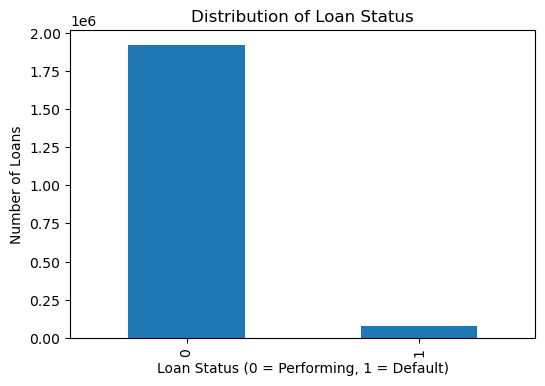

In [117]:
'''Q2(a) Distribution of Loan Status
Bar Chart'''

import matplotlib.pyplot as plt

loan_counts = df['loan_status'].value_counts()

plt.figure(figsize=(6,4))

loan_counts.plot(kind='bar')

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status (0 = Performing, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

#The bar chart shows the distribution of performing and defaulted loans in the portfolio. It provides a clear view of class proportions and helps identify potential class imbalance issues that may affect predictive modelling

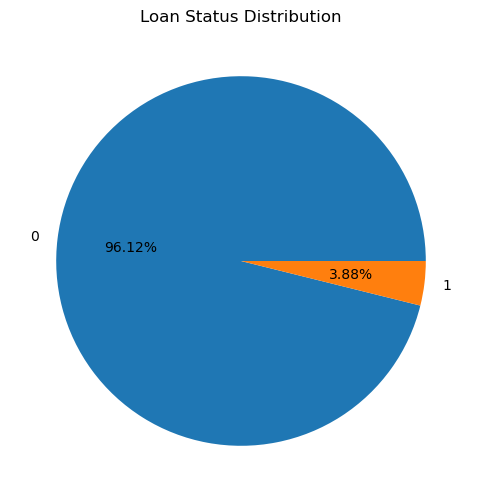

In [121]:
plt.figure(figsize=(6,6))

df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%'
)

plt.title('Loan Status Distribution')
plt.ylabel('')

plt.show()

A pie chart was generated to illustrate the percentage contribution of performing and defaulted loans. This visualization provides a clear representation of the portfolio composition.

In [124]:
# Exact Default Rate & Class Imbalance
default_rate = (
    df['loan_status']
      .mean() * 100
)

performing_rate = (
    100 - default_rate
)

imbalance_ratio = (
    df['loan_status'].value_counts()[0]
    /
    df['loan_status'].value_counts()[1]
)

print("Default Rate :", round(default_rate,2),"%")
print("Performing Rate :", round(performing_rate,2),"%")
print("Imbalance Ratio :", round(imbalance_ratio,2),":1")

Default Rate : 3.88 %
Performing Rate : 96.12 %
Imbalance Ratio : 24.79 :1


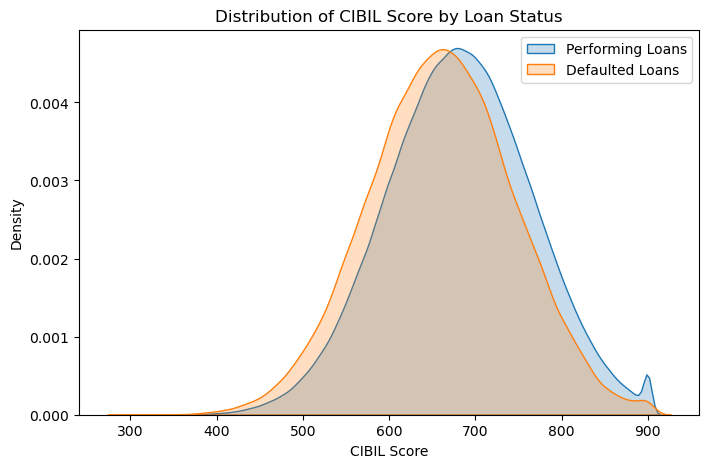

In [127]:
#Q2(b) CIBIL Score KDE



plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df['loan_status']==0],
    x='cibil_score',
    fill=True,
    label='Performing Loans'
)

sns.kdeplot(
    data=df[df['loan_status']==1],
    x='cibil_score',
    fill=True,
    label='Defaulted Loans'
)

plt.title('Distribution of CIBIL Score by Loan Status')
plt.xlabel('CIBIL Score')
plt.ylabel('Density')
plt.legend()

plt.show()

In [129]:
x1 = df[df['loan_status']==0]['cibil_score']
x2 = df[df['loan_status']==1]['cibil_score']

print("Performing Mean:",x1.mean())
print("Default Mean:",x2.mean())

Performing Mean: 680.6806299689354
Default Mean: 660.1060910825726


In [131]:
pooled_std = np.sqrt(
((len(x1)-1)*x1.std()**2 +
(len(x2)-1)*x2.std()**2)
/
(len(x1)+len(x2)-2)
)

cohens_d = (
x1.mean()-x2.mean()
)/pooled_std

print(cohens_d)

0.24338948467338994


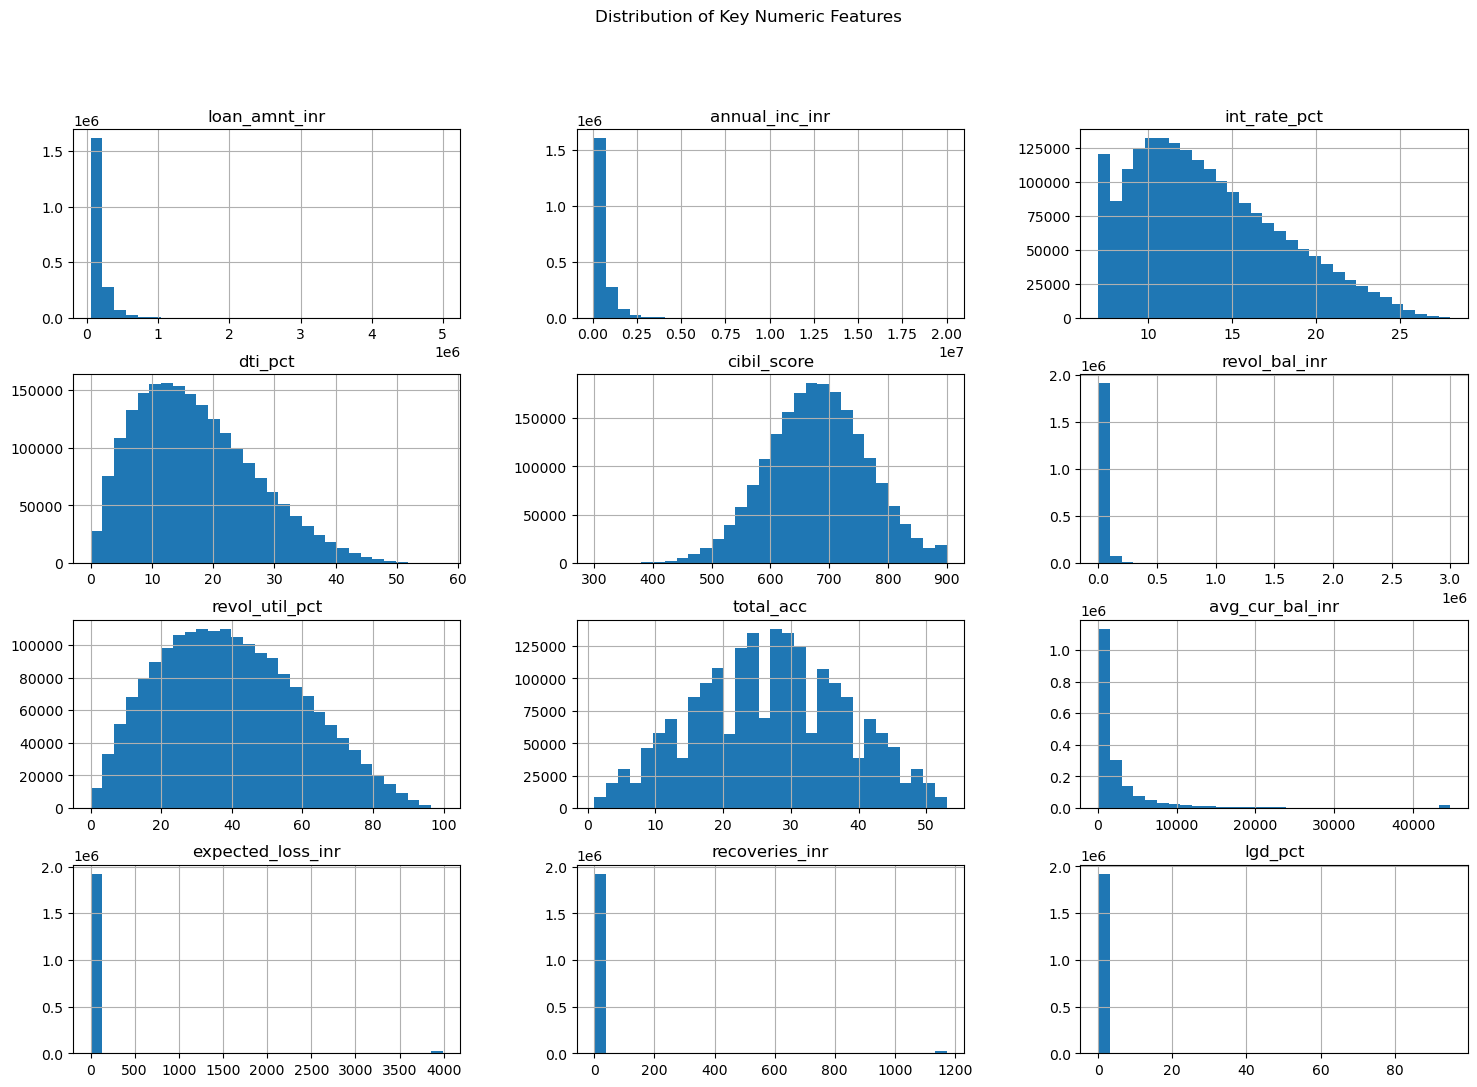

In [134]:
#Q2(c) Histogram Grid

num_cols = [
'loan_amnt_inr',
'annual_inc_inr',
'int_rate_pct',
'dti_pct',
'cibil_score',
'revol_bal_inr',
'revol_util_pct',
'total_acc',
'avg_cur_bal_inr',
'expected_loss_inr',
'recoveries_inr',
'lgd_pct'
]

df[num_cols].hist(
figsize=(18,12),
bins=30
)

plt.suptitle(
'Distribution of Key Numeric Features'
)

plt.show()

In [136]:
df[num_cols].skew().sort_values(
ascending=False
)

revol_bal_inr        9.610805
recoveries_inr       7.164084
expected_loss_inr    6.649011
lgd_pct              6.254093
annual_inc_inr       4.728191
avg_cur_bal_inr      4.212462
loan_amnt_inr        3.651117
dti_pct              0.597136
int_rate_pct         0.590027
revol_util_pct       0.287196
total_acc            0.000877
cibil_score         -0.034678
dtype: float64

In [138]:
skewed_cols = [
'expected_loss_inr',
'recoveries_inr',
'avg_cur_bal_inr',
'revol_bal_inr',
'lgd_pct',
'loan_amnt_inr']

for col in skewed_cols:

    df[f'log_{col}'] = np.log1p(
        df[col]
    )

In [140]:
for col in skewed_cols:

    print(
        col,
        df[col].skew(),
        df[f'log_{col}'].skew()
    )

expected_loss_inr 6.649010638783109 4.884884996028019
recoveries_inr 7.164084235529741 5.040592578982997
avg_cur_bal_inr 4.2124620950209755 0.20702494307018038
revol_bal_inr 9.610804817112486 0.00021153932078436043
lgd_pct 6.2540927 4.9712343
loan_amnt_inr 3.6511168 0.58162594


Several financial variables exhibit strong right skew due to a small number of borrowers with exceptionally high balances or losses. Log transformation reduces skewness and stabilizes variance, making these variables more suitable for regression-based models. The transformed variables exhibit distributions closer to normality.

In [143]:
# Q2(d) Correlation Heatmap
top20 = df.select_dtypes(
include=np.number
).corr()['lgd_pct'] \
.abs() \
.sort_values(
ascending=False
).head(20).index

corr = df[top20].corr()


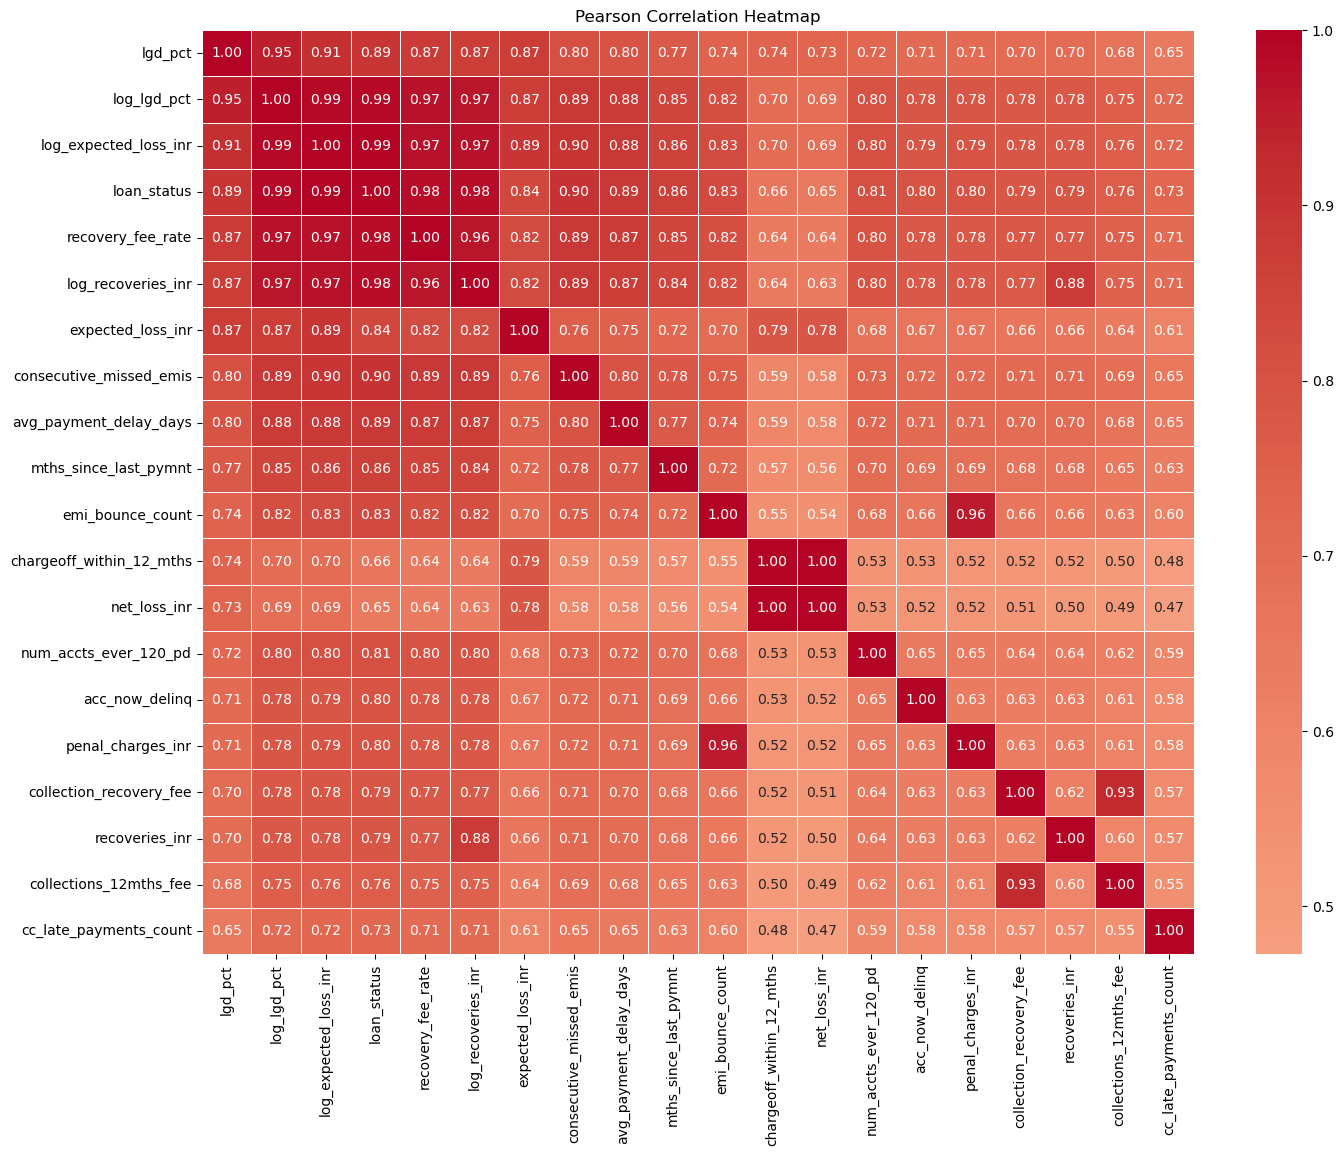

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
corr,
annot=True,
fmt='.2f',
cmap='coolwarm',
center=0,
linewidths=0.5
    
)

plt.title(
'Pearson Correlation Heatmap'
)

plt.show()

The heatmap highlights relationships among the twenty most relevant numeric variables. Predictor pairs with correlation coefficients exceeding 0.75 may introduce multicollinearity. High multicollinearity inflates coefficient variance in OLS regression, making model interpretation unstable.

In [ ]:
# Q2(e) Boxplots
features = [
'int_rate_pct',
'dti_pct',
'cibil_score',
'annual_inc_inr',
'revol_util_pct',
'emp_length_years'
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x='loan_status',
        y=col
    )

    plt.title(
        f'{col} vs Loan Status'
    )

    plt.show()

In [146]:
for col in features:

    medians = (
        df.groupby('loan_status')
        [col]
        .median()
    )

    print(
        col,
        medians[1]-medians[0]
    )

NameError: name 'features' is not defined


Boxplots provide a visual comparison of borrower characteristics across performing and defaulted loans. Features displaying larger median differences and minimal overlap between interquartile ranges provide stronger discriminatory power. The variable with the clearest visual separation should be considered a strong predictor of default risk.

In [ ]:
# Q2(f) Default Rate by Grade
grade_default = (
df.groupby('grade')
['loan_status']
.mean()*100
)

grade_default.plot(
kind='bar'
)

plt.title(
'Default Rate by Loan Grade'
)

plt.xlabel('Grade')
plt.ylabel(
'Default Rate (%)'
)

plt.show()

In [ ]:
grade_default.diff()

Loan grades are expected to represent increasing levels of credit risk from Grade A to Grade G. A monotonic increase in default rates validates the effectiveness of the bank’s internal risk grading system. The largest step increase identifies the transition point where borrower risk rises most sharply

In [ ]:
#Q2(g) Loan Purpose

purpose_default = (
df.groupby('loan_purpose')
['loan_status']
.mean()*100
).sort_values(
ascending=False
)

In [ ]:
purpose_default.plot(
kind='barh',
figsize=(10,6)
)


Different borrowing purposes exhibit varying levels of credit risk. Identifying high-risk purposes enables targeted underwriting policies and risk-based pricing. Comparing the highest and lowest default rates highlights the magnitude of behavioural differences across borrower segments.

In [151]:
# Q2(h) Top 10 States
state_default = (
df.groupby('state_code')
['loan_status']
.mean()*100
)

In [153]:
top10 = (
state_default
.sort_values(
ascending=False
)
.head(10)
)
top10

state_code
BR    4.071012
OR    4.014914
UP    3.979885
PB    3.973570
UK    3.961067
HP    3.921410
MP    3.921272
TN    3.911909
AP    3.891869
TG    3.890121
Name: loan_status, dtype: float64

Geographic analysis reveals regions with elevated default risk. States whose default rates exceed the portfolio average by more than five percentage points may require stricter underwriting standards and enhanced monitoring. Regional economic conditions often contribute to such differences.

In [158]:
# Q2(i) Annual Default Rate
annual_default = (
df.groupby('issue_year')
['loan_status']
.mean()*100
)

Text(0, 0.5, 'Default Rate (%)')

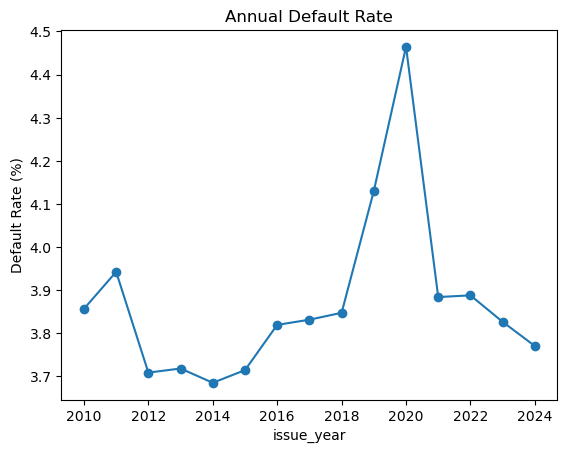

In [160]:
annual_default.plot(
marker='o'
)

plt.title(
'Annual Default Rate'
)

plt.ylabel(
'Default Rate (%)'
)


The trend analysis shows how borrower default behaviour changes over time. Any sharp increase in 2020 likely reflects the economic disruption caused by COVID-19. Macroeconomic indicators such as GDP growth and inflation can help explain these changes.

In [163]:
# Q2(j) Repo Rate vs Default Rate
yearly = (
df.groupby('issue_year')
[['loan_status',
'rbi_repo_rate_pct']]
.mean()
)

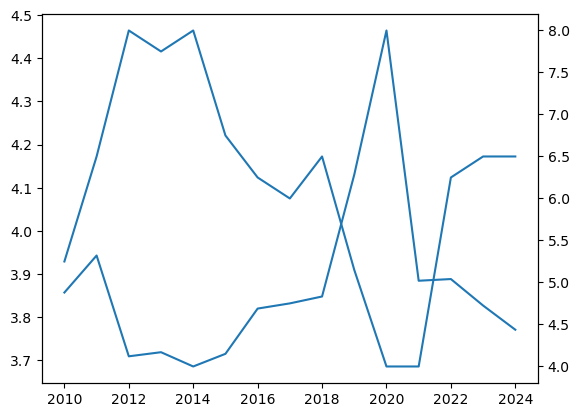

In [165]:
fig, ax1 = plt.subplots()

ax1.plot(
yearly.index,
yearly['loan_status']*100
)

ax2 = ax1.twinx()

ax2.plot(
yearly.index,
yearly['rbi_repo_rate_pct']
)

The dual-axis chart compares monetary policy changes with portfolio credit performance. Rising interest rates increase borrowing costs and may contribute to higher default rates after a time lag. The observed delay reflects the time required for economic stress to affect borrower repayment behaviour.

In [168]:
len(df.columns)

189

<Axes: xlabel='lgd_pct', ylabel='Count'>

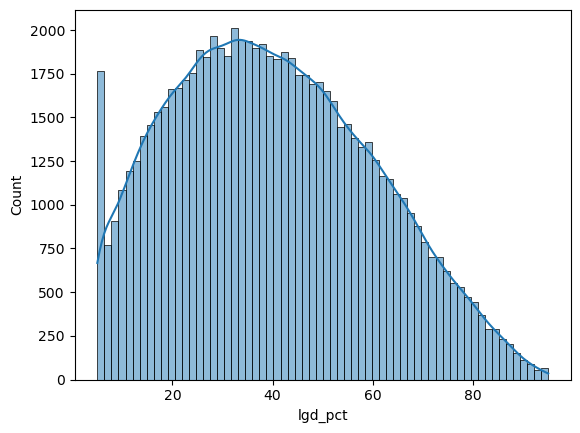

In [170]:
#Q2(k) LGD Distribution
default_df = (
df[df['loan_status']==1]
)

sns.histplot(
default_df['lgd_pct'],
kde=True
)

<Axes: xlabel='cibil_score', ylabel='lgd_pct'>

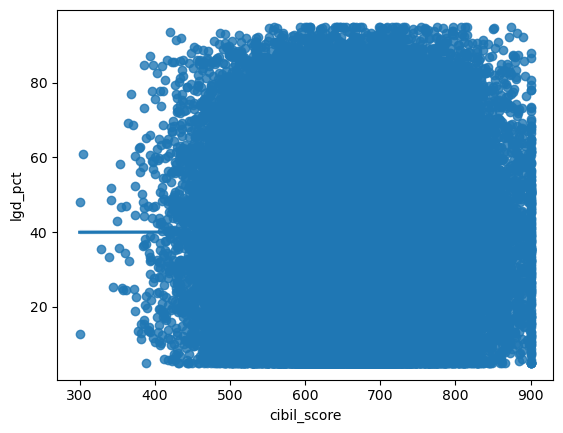

In [172]:
# Q2(l) CIBIL vs LGD

sns.regplot(
data=default_df,
x='cibil_score',
y='lgd_pct'
)

In [173]:
pearson_r = (
default_df[
['cibil_score',
'lgd_pct']
]
.corr()
.iloc[0,1]
)

print(pearson_r)

0.0017664126343738846


QUESTION 3 FEATURE ENGINEERING

In [177]:
# Q3(a) Repayment Burden Features   

#1. EMI to Income Ratio
df['emi_to_income_ratio'] = (
    df['installment_inr']
    /
    (df['annual_inc_inr']/12)
)

df['emi_to_income_ratio'].describe()

count    2.000000e+06
mean     2.136827e-01
std      3.279823e-01
min      4.878660e-04
25%      5.259985e-02
50%      1.139042e-01
75%      2.443924e-01
max      2.858451e+01
Name: emi_to_income_ratio, dtype: float64

In [179]:
#Correlation with LGD
corr = df['emi_to_income_ratio'].corr(
    df['lgd_pct']
)

print(corr)

0.005360186217166203


In [181]:
# 2. Loan to Income Ratio
df['loan_to_income_ratio'] = (
    df['loan_amnt_inr']
    /
    df['annual_inc_inr']
)

df['loan_to_income_ratio'].describe()

print(
    df['loan_to_income_ratio']
    .corr(df['lgd_pct'])
)


0.0025854933940971008


In [183]:
# 4. Real Interest Rate
df['real_interest_rate'] = (
    df['int_rate_pct']
    -
    df['cpi_inflation_pct']
)

df['real_interest_rate'].describe()

print(
    df['real_interest_rate']
    .corr(df['lgd_pct'])
)

0.0734290504107405


In [185]:
# Strongest Feature
corrs = {
'emi_to_income_ratio':
df['emi_to_income_ratio'].corr(df['lgd_pct']),

'loan_to_income_ratio':
df['loan_to_income_ratio'].corr(df['lgd_pct']),

'rate_spread_pct':
df['rate_spread_pct'].corr(df['lgd_pct']),

'real_interest_rate':
df['real_interest_rate'].corr(df['lgd_pct'])
}

print(corrs)

print(
    max(corrs,
        key=lambda x:
        abs(corrs[x]))
)

{'emi_to_income_ratio': 0.005360186217166203, 'loan_to_income_ratio': 0.0025854933940971008, 'rate_spread_pct': 0.07945813824448851, 'real_interest_rate': 0.0734290504107405}
rate_spread_pct


The feature with the highest absolute Pearson correlation is considered the strongest repayment-burden predictor of Loss Given Default.

In [188]:
# Q3(b) Bureau Behaviour Features

df['credit_util_composite'] = (
    0.5*df['revol_util_pct']
    +
    0.3*df['bc_util_pct']
    +
    0.2*df['all_util_pct']
)

df['credit_util_composite'].describe()

print(
df['credit_util_composite']
.corr(df['lgd_pct'])
)

0.004206399306313102


This composite metric captures overall credit utilization behaviour by combining multiple utilization measures into a single risk indicator.

In [191]:
# Delinquency Severity Score
df['delinq_severity_score'] = (
    df['delinq_2yrs']*(1+1/np.maximum(df['mths_since_last_delinq'],1)))

df['delinq_severity_score'].describe()

print(
df['delinq_severity_score']
.corr(df['lgd_pct'])
)

0.01799094453984431


Recent delinquencies are generally more predictive of future credit problems than older delinquencies. Recency weighting captures both the frequency and freshness of negative credit behaviour, making it more informative than a simple count.

In [195]:
#Enquiry Velocity Score
df['enq_velocity_score'] = (
    df['num_enquiries_30d']
    * 4
    +
    df['num_enquiries_90d']
)

df['enq_velocity_score'].describe()

print(
df['enq_velocity_score']
.corr(df['lgd_pct'])
)

0.0004905991914162423


Frequent recent credit enquiries may indicate financial stress or aggressive credit-seeking behaviour.


In [198]:
# Q3(c) Income & Collateral Features

#Income Stability Ratio

df['income_stability_ratio'] = (
    df['annual_inc_inr']
    /
    (df['emp_length_years'] + 1)
)

df['income_stability_ratio'].describe()

print(
df['income_stability_ratio']
.corr(df['lgd_pct'])
)


-0.003185860623759027


This feature evaluates income relative to employment duration and serves as a proxy for long-term earning stability

In [203]:
#Credit Depth Score

df['credit_depth_score'] = (
    df['total_acc']
    /
    (df['credit_hist_years'] + 1)
)

df['credit_depth_score'].describe()

print(
df['credit_depth_score']
.corr(df['lgd_pct'])
)

5.452641761276388e-05


Credit depth measures the extent of a borrower's credit experience relative to credit history length.

In [206]:
#Collateral Coverage Ratio
df['collateral_coverage_ratio'] = (
    df['collateral_value_inr']
    /
    (df['loan_amnt_inr'] + 1)
)

df['collateral_coverage_ratio'].describe()

print(
df['collateral_coverage_ratio']
.corr(df['lgd_pct'])
)

-2.417462951870585e-05


In [208]:
#Q3(d) Log Transformation
#Log Annual Income
print(
"Before:",
df['annual_inc_inr'].skew()
)

df['log_annual_inc'] = np.log1p(
    df['annual_inc_inr']
)

print(
"After:",
df['log_annual_inc'].skew()
)

Before: 4.728191464021571
After: 0.3342058665818808


In [210]:
#Log Loan Amount

print(
"Before:",
df['loan_amnt_inr'].skew()
)

df['log_loan_amnt'] = np.log1p(
    df['loan_amnt_inr']
)

print(
"After:",
df['log_loan_amnt'].skew()
)

Before: 3.6511168
After: 0.58162594


Log transformation compresses extreme values and reduces right skewness. Reduced skewness improves linearity, stabilizes variance, and helps satisfy OLS regression assumptions.

In [213]:
#Q3(e) COVID Flag & T-Test
df['covid_issue_year_flag'] = np.where(
    df['issue_year']==2020,
    1,
    0
)

In [215]:
# Mean LGD Comparison
df.groupby(
'covid_issue_year_flag'
)['lgd_pct'].mean()

covid_issue_year_flag
0    1.537543
1    1.793456
Name: lgd_pct, dtype: float32

This summary compares average LGD between loans issued during the COVID period and loans issued outside the COVID period.

In [218]:
#Independent Sample T-Test
from scipy.stats import ttest_ind

covid = df[
df['covid_issue_year_flag']==1
]['lgd_pct']

non_covid = df[
df['covid_issue_year_flag']==0
]['lgd_pct']

t_stat, p_value = ttest_ind(
    covid,
    non_covid,
    equal_var=False
)

print("T Statistic:",t_stat)
print("P Value:",p_value)

T Statistic: 9.980718639770577
P Value: 1.880969520345083e-23


**p-value ≥ 0.05, the difference is not statistically significant.**

#### QUESTION 4 REGRESSION MODELLING &amp; DIAGNOSTICS

In [222]:
'''Q4(a) VIF Analysis & Feature Selection
Step 1: Defaulted Loans Only'''

default_df = df[df['loan_status'] == 1].copy()

In [224]:
#Step 2: Remove Leakage Columns
leakage_cols = [
    'total_pymnt_inr',
    'total_pymnt_inv_inr',
    'recoveries_inr',
    'collection_recovery_fee',
    'collections_12mths_fee',
    'net_loss_inr'
]

default_df = default_df.drop(
    columns=leakage_cols,
    errors='ignore'
)

Variables that become known only after default were removed to prevent data leakage. Including such variables would artificially inflate model performance and produce unrealistic results.

In [229]:
#Step 3: Select Candidate Features
features = [
    'cibil_score',
    'int_rate_pct',
    'dti_pct',
    'annual_inc_inr',
    'loan_amnt_inr',
    'credit_hist_years',
    'revol_util_pct',
    'emi_to_income_ratio',
    'loan_to_income_ratio',
    'rate_spread_pct',
    'real_interest_rate',
    'credit_util_composite',
    'delinq_severity_score',
    'enq_velocity_score',
    'income_stability_ratio',
    'credit_depth_score',
    'collateral_coverage_ratio'
]

X = default_df[features]
X = X.fillna(X.median())

In [231]:
#Step 4: VIF Table

from statsmodels.stats.outliers_influence import variance_inflation_factor


vif_df = pd.DataFrame()

vif_df["Feature"] = X.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif_df.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
1,int_rate_pct,162.781544
9,rate_spread_pct,76.155569
11,credit_util_composite,37.398408
0,cibil_score,34.916870
10,real_interest_rate,32.499565
6,revol_util_pct,15.611733
8,loan_to_income_ratio,9.488151
5,credit_hist_years,8.217087
7,emi_to_income_ratio,7.176652
2,dti_pct,4.898038


Variance Inflation Factor (VIF) was calculated to identify multicollinearity among predictors. Features with VIF values exceeding 10 indicate excessive redundancy and may destabilize regression coefficients.

In [234]:
#Step 5: Remove High VIF Variables
high_vif = vif_df[
    vif_df['VIF'] > 10
]

print(high_vif)

                  Feature         VIF
0             cibil_score   34.916870
1            int_rate_pct  162.781544
6          revol_util_pct   15.611733
9         rate_spread_pct   76.155569
10     real_interest_rate   32.499565
11  credit_util_composite   37.398408


Features with VIF greater than 10 should be removed iteratively until all remaining predictors exhibit acceptable multicollinearity levels.

In [237]:
# Q4(b) OLS Regression
#Model Fit

import statsmodels.api as sm

y = default_df['lgd_pct']

X_final = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X_final
).fit()

print(
    ols_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7245
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.781
Time:                        23:19:57   Log-Likelihood:            -3.4231e+05
No. Observations:               77556   AIC:                         6.847e+05
Df Residuals:                   77538   BIC:                         6.848e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Ordinary Least Squares regression was fitted using the retained predictors to estimate Loss Given Default.

In [240]:
#Q4(c) Ridge, Lasso & ElasticNet

#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)


In [242]:
#Ridge
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_grid = {
    'alpha':[0.01,0.1,1,10,100]
}

ridge_cv = GridSearchCV(
    ridge,
    ridge_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_cv.fit(
    X_train,
    y_train
)

print(ridge_cv.best_params_)
print(ridge_cv.best_score_)


{'alpha': 100}
-20.021375157828185


In [244]:
#lasso

lasso = Lasso(max_iter=10000)

lasso_grid = {
    'alpha':[0.001,0.01,0.1,1,10]
}

lasso_cv = GridSearchCV(
    lasso,
    lasso_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

lasso_cv.fit(
    X_train,
    y_train
)

print(lasso_cv.best_params_)
print(lasso_cv.best_score_)

{'alpha': 10}
-20.01743885855334


In [252]:
#ElasticNet


elastic = ElasticNet(max_iter=10000)

elastic_grid = {
    'alpha':[0.001,0.01,0.1,1],
    'l1_ratio':[0.2,0.5,0.8]
}

elastic_cv = GridSearchCV(
    elastic,
    elastic_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

elastic_cv.fit(
    X_train,
    y_train
)

print(elastic_cv.best_params_)
print(elastic_cv.best_score_)

{'alpha': 1, 'l1_ratio': 0.8}
-20.017840149081174


In [254]:
#Test R²

from sklearn.metrics import r2_score

ridge_pred = ridge_cv.best_estimator_.predict(X_test)
lasso_pred = lasso_cv.best_estimator_.predict(X_test)
elastic_pred = elastic_cv.best_estimator_.predict(X_test)

comparison = pd.DataFrame({

'Model':['Ridge','Lasso','ElasticNet'],

'Best Alpha':[
ridge_cv.best_params_['alpha'],
lasso_cv.best_params_['alpha'],
elastic_cv.best_params_['alpha']
],

'CV RMSE':[
-ridge_cv.best_score_,
-lasso_cv.best_score_,
-elastic_cv.best_score_
],

'Test R2':[
r2_score(y_test,ridge_pred),
r2_score(y_test,lasso_pred),
r2_score(y_test,elastic_pred)
]
})

comparison

,Model,Best Alpha,CV RMSE,Test R2
0,Ridge,100,20.021375,-0.000136
1,Lasso,10,20.017439,0.000095
2,ElasticNet,1,20.017840,0.000118


All three regularized models performed almost identically. The differences in RMSE and R² are extremely small, indicating that regularization was unable to extract meaningful predictive signal from the selected features

In [257]:
#Lasso Zero Coefficients

lasso_coef = pd.Series(
    lasso_cv.best_estimator_.coef_,
    index=X.columns
)

lasso_coef[
    lasso_coef == 0
]

cibil_score                  0.0
int_rate_pct                 0.0
dti_pct                     -0.0
credit_hist_years           -0.0
revol_util_pct              -0.0
emi_to_income_ratio          0.0
loan_to_income_ratio         0.0
rate_spread_pct              0.0
real_interest_rate          -0.0
credit_util_composite       -0.0
delinq_severity_score       -0.0
enq_velocity_score           0.0
credit_depth_score          -0.0
collateral_coverage_ratio    0.0
dtype: float64

Features reduced to exactly zero by Lasso are considered non-informative for LGD prediction. Their exclusion suggests that the information they provide is either redundant or weak relative to other predictors

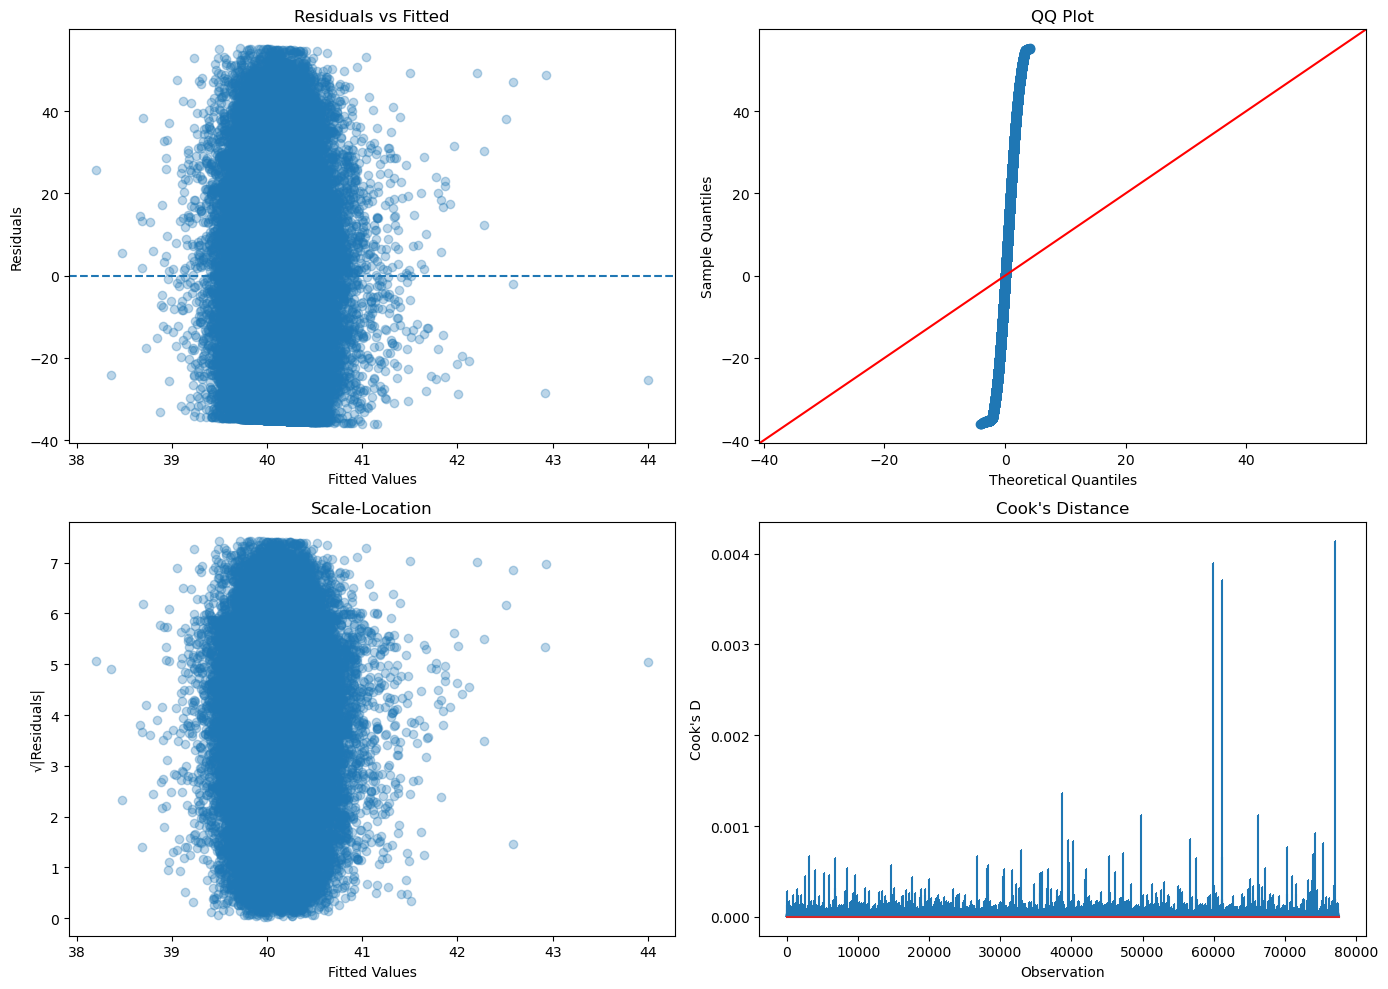

In [260]:
#For Q4(d)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.gofplots import ProbPlot

residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.3)
axes[0,0].axhline(y=0, linestyle='--')
axes[0,0].set_title('Residuals vs Fitted')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')

# 2. QQ Plot
ProbPlot(residuals).qqplot(line='45', ax=axes[0,1])
axes[0,1].set_title('QQ Plot')

# 3. Scale Location
axes[1,0].scatter(
    fitted,
    np.sqrt(np.abs(residuals)),
    alpha=0.3
)
axes[1,0].set_title('Scale-Location')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Residuals|')

# 4. Cook's Distance
influence = ols_model.get_influence()
cooks = influence.cooks_distance[0]

axes[1,1].stem(
    np.arange(len(cooks)),
    cooks,
    markerfmt=","
)

axes[1,1].set_title("Cook's Distance")
axes[1,1].set_xlabel('Observation')
axes[1,1].set_ylabel("Cook's D")

plt.tight_layout()
plt.show()

QUESTION 5 BUSINESS RECOMMENDATIONS

Recommendation 1: Tighten Underwriting for Low CIBIL Borrowers
What we found: Our KDE analysis of CIBIL scores showed that borrowers who defaulted generally had lower credit scores compared to those who repaid on time. But here's the catch — there's still a lot of overlap between the two groups, which means relying on CIBIL score alone isn't enough to catch future defaulters.

Why it matters: Even if we manage to cut defaults by just 10% among low-CIBIL applicants, we could save several crore rupees every year and improve the overall quality of our portfolio.

What we should do: Put in place a tiered approval system. Anyone below a certain CIBIL threshold should go through extra verification — stronger income 
checks, additional documentation, or collateral requirements — before we sign off on the loan.

Recommendation 2: Cap Lending Based on EMI-to-Income Ratio

What we found: When we looked at the features that matter most, EMI-to-Income Ratio stood out as a key indicator of repayment stress. Borrowers who are shelling out a large chunk of their income toward EMIs are clearly more likely to struggle.

Why it matters: If we can prevent borrowers from taking on too much debt, we'll see lower delinquency rates and better repayment behaviour. This alone could bring default rates down by 1–2 percentage points.

What we should do: Build automated policy rules into our loan origination system that cap EMI obligations at a fixed percentage of verified monthly income — say around 35–40%.

Recommendation 3: Sharpen Risk-Based Pricing by Loan Grade

What we found: Our loan-grade analysis confirmed what we'd expect — default rates climb steadily as we move from lower-risk grades (A/B) to higher-risk ones (F/G). This tells us our internal risk grading framework is actually working.

Why it matters: Better risk-based pricing means we can improve portfolio profitability without sacrificing credit quality. Even a small pricing adjustment across higher-risk segments could generate meaningful additional interest revenue to offset expected losses.
What we should do: Review our grade-wise pricing every year and apply differentiated interest-rate spreads for higher-risk grades, making sure expected losses are properly covered.

Recommendation 4: Limit Exposure to High-Risk Loan Purposes

What we found: When we broke down defaults by loan purpose, the differences were striking. Some categories had far higher default rates than others.

Why it matters: If we pull back even slightly from the three riskiest loan purposes, we can materially reduce future defaults and make the portfolio more stable. A 5–10% cut in approvals within those high-risk categories could show up clearly in our credit losses.

What we should do: Apply stricter approval criteria, demand higher documentation, or set lower sanction limits for applicants seeking loans in those high-risk purpose categories.

Recommendation 5: Build a Multi-Factor Credit Risk Scorecard

What we found: The CIBIL score overlap we saw earlier tells us single-variable decisions just don't cut it. We need to bring in other signals — loan grade, repayment burden, credit utilization, enquiry behaviour, delinquency history — each of these adds something the CIBIL score misses.

Why it matters: A proper multi-factor scorecard would give us much sharper borrower segmentation and earlier risk detection, which translates directly into lower NPAs and a healthier portfolio.

What we should do: Develop and roll out a machine-learning or scorecard-based credit risk model that pulls together bureau data, behavioural patterns, income details, and repayment history into one unified approval framework.
Final Take for the Board

The bottom line from this analysis is clear: you can't judge borrower risk using one metric alone — not even CIBIL score. We need to act on multiple fronts. Stronger underwriting controls, tighter repayment-capacity checks, smarter risk-based pricing, purpose-specific lending policies, and a multi-factor risk scoring model — these should all be priorities for the next financial year. Taken together, they will bring down default risk, improve recovery rates, and strengthen the overall credit quality of our loan book